In [93]:
# ===============================
# import packages
# ===============================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datetime import datetime as dt, timezone, timedelta
from pathlib import Path
import squarify
from highlight_text import ax_text
import traceback
from instagrapi import Client
from dotenv import load_dotenv
import os

In [94]:
import sys
print("Notebook is running on:")
print(sys.executable)

Notebook is running on:
c:\Users\Harry Turner\Documents\Personal Projects\01_2026\GridProject\venv\Scripts\python.exe


In [95]:
# ===============================
# system paths
# ===============================
script_dir = Path.cwd().parent
output_dir = script_dir / "data"

output_dir.mkdir(parents=True, exist_ok=True)

In [96]:
# ===============================
# 1 - Elexon generation data
# ===============================
# API request - generation data
url = 'https://data.elexon.co.uk/bmrs/api/v1/generation/outturn/summary'
today = dt.now(timezone.utc)
time_lag = timedelta(days=7)
start_date = pd.Timestamp(today - time_lag).round('D').strftime('%Y-%m-%d %H:%M:%S')
today = pd.Timestamp(today).strftime('%Y-%m-%d %H:%M:%S')

params = {
    'startTime' : start_date,
    'endTime' : today
}

response = requests.get(url, params = params)

if response.status_code == 200:
    print('Elexon generation API call successful!')
else:
    raise Exception(f"Elexon API failed. Status code: {response.status_code}")

gen = response.json()

gen = pd.json_normalize(
    gen,
    record_path=['data'],
    meta=['startTime', 'settlementPeriod']
)

# Convert data types - generation data
gen['settlementPeriod'] = pd.to_numeric(gen['settlementPeriod'])
gen['localTime'] = pd.to_datetime(gen['startTime'], utc=True).dt.tz_convert('Europe/London')
gen['startTime'] = gen['localTime'].dt.strftime('%Y-%m-%d')

gen = gen.pivot_table(
    index=['startTime', 'settlementPeriod'],
    columns='fuelType',
    values='generation'
).reset_index().rename_axis(None, axis=1)

Elexon generation API call successful!


In [97]:
# ===============================
# 2 - NESO demand data
# ===============================
# API request - NESO demand data
dmnd = pd.read_csv('https://api.neso.energy/dataset/7a12172a-939c-404c-b581-a6128b74f588/resource/177f6fa4-ae49-4182-81ea-0c6b35f26ca6/download/demanddataupdate.csv')

dmnd = pd.DataFrame(dmnd)

dmnd = dmnd.rename(
    columns={
        'SETTLEMENT_DATE': 'startTime',
        'SETTLEMENT_PERIOD': 'settlementPeriod'
    }
)

In [98]:
merged_data = pd.merge(dmnd, gen, on=['startTime', 'settlementPeriod'])


merged_data.columns

grid = merged_data[[
    'startTime',
    'settlementPeriod',
    'OIL',
    'CCGT',
    'OCGT',
    'COAL',
    'BIOMASS',
    'NUCLEAR',
    'WIND',
    'EMBEDDED_WIND_GENERATION',
    'EMBEDDED_SOLAR_GENERATION',
    'NPSHYD',
    'PS',
    'OTHER',
    'INTELEC',
    'INTFR',
    'INTIFA2',
    'INTNED',
    'INTIRL',
    'INTEW',
    'INTNEM',
    'INTNSL',
    'INTVKL'
]]


In [99]:
grid['startTime'] = pd.to_datetime(grid['startTime'])
grid['timestamp'] = grid['startTime'] + pd.to_timedelta((grid['settlementPeriod'] -1) * 30, unit='m')

grid = grid.drop('startTime', axis='columns')

grid = (
    grid
    .rename(columns={
        'OIL': 'oil',
        'CCGT': 'ccgt',
        'OCGT': 'ocgt',
        'COAL': 'coal',
        'BIOMASS': 'biomass',
        'NUCLEAR': 'nuclear',
        'WIND': 'wind',
        'EMBEDDED_WIND_GENERATION': 'wind_embedded',
        'EMBEDDED_SOLAR_GENERATION': 'solar',
        'PS': 'pumped_storage_hydro',
        'NPSHYD': 'non_pumped_storage_hydro',
        'OTHER': 'other'
    })
    .assign(
        gas = lambda x: x['ocgt'] + x['ccgt'],
        wind = lambda x: x['wind'] + x['wind_embedded'],
        hydro = lambda x: x['pumped_storage_hydro'] + x['non_pumped_storage_hydro']
    )
)

grid = grid.drop(columns=['ocgt', 'ccgt', 'wind_embedded', 'pumped_storage_hydro', 'non_pumped_storage_hydro', 'other'])

start_cols = ['timestamp', 'settlementPeriod', 'gas']
ordered_cols = start_cols + [c for c in grid.columns if c not in start_cols]
grid = grid[ordered_cols]
grid = grid.fillna(0)

print(grid.columns)

Index(['timestamp', 'settlementPeriod', 'gas', 'oil', 'coal', 'biomass',
       'nuclear', 'wind', 'solar', 'INTELEC', 'INTFR', 'INTIFA2', 'INTNED',
       'INTIRL', 'INTEW', 'INTNEM', 'INTNSL', 'INTVKL', 'hydro'],
      dtype='str')


In [100]:
energy_categories = { 
    'gas': 'Fossil', 
    'oil': 'Fossil', 
    'coal': 'Fossil', 
    'biomass': 'Other',
    'nuclear': 'Other', 
    'wind': 'Renewable',
    'solar': 'Renewable', 
    'hydro': 'Renewable',
    'other': 'Other', 
    'INTELEC': 'Interconnector', 
    'INTFR': 'Interconnector', 
    'INTIFA2': 'Interconnector',
    'INTNED': 'Interconnector', 
    'INTIRL': 'Interconnector', 
    'INTEW': 'Interconnector', 
    'INTGRNL': 'Interconnector', 
    'INTNEM': 'Interconnector', 
    'INTNSL': 'Interconnector', 
    'INTVKL': 'Interconnector'
}

grid_long = grid.melt(id_vars=['timestamp', 'settlementPeriod'],
                      var_name='source',
                      value_name='mw')

grid_long['category'] = grid_long['source'].map(energy_categories)

category_df = grid_long.groupby(['timestamp', 'category'])['mw'].sum().unstack(level='category')

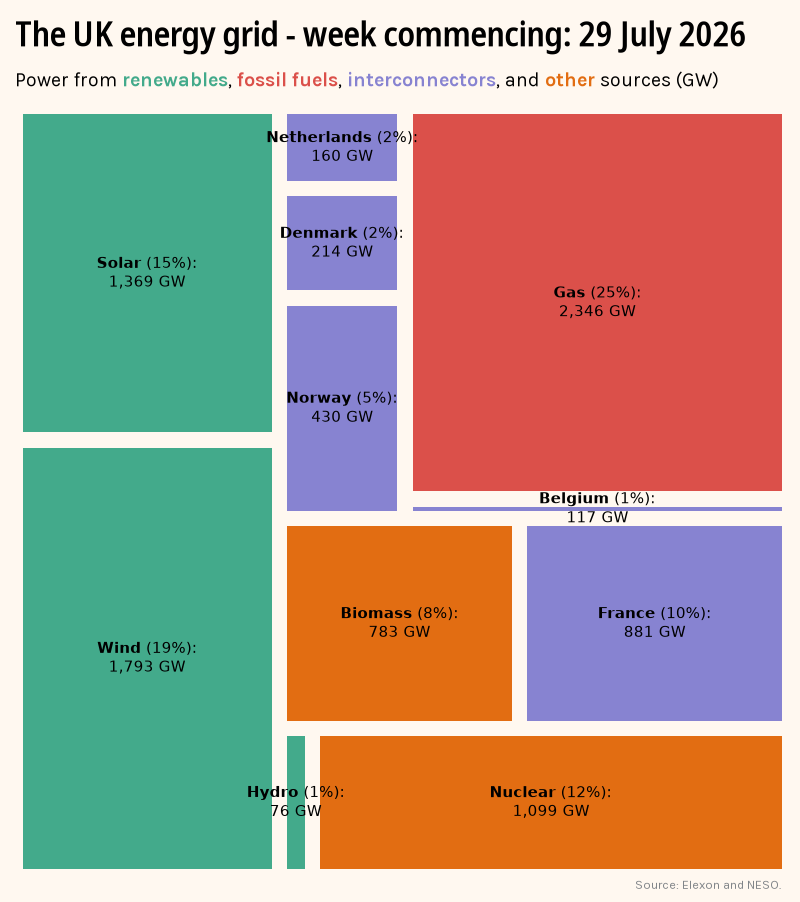

In [101]:
# treemap data preparation
heatmap_data = grid_long.groupby(['category', 'source'], as_index=False)['mw'].sum()
heatmap_data = heatmap_data[heatmap_data['mw'] > 0].dropna(subset='mw')

# interconnector connecting countries
interconnector_map = {
    'INTELEC': 'France', 
        'INTFR': 'France', 
        'INTIFA2': 'France',
        'INTNED': 'Netherlands', 
        'INTIRL': 'Ireland', 
        'INTEW': 'Ireland', 
        'INTGRNL': 'Ireland', 
        'INTNEM': 'Belgium', 
        'INTNSL': 'Norway', 
        'INTVKL': 'Denmark'
}

# prepare final plot DataFrame
heatmap_data['type'] = heatmap_data['source'].map(interconnector_map).fillna(heatmap_data['source'])
heatmap_data = heatmap_data.groupby(['category', 'type'], as_index=False)['mw'].sum()
heatmap_data = heatmap_data[heatmap_data['mw'] >= 10000]
heatmap_data['proportion'] = ((heatmap_data['mw'] / heatmap_data['mw'].sum()) * 100).round().astype(int)


pd.Categorical(heatmap_data['category'], ['Renewable', 'Fossil', 'Interconnector', 'Other'])
heatmap_data = heatmap_data.sort_values(by=['category','mw'], ascending=[False, False])


labels = [
    f"$\\bf{{{type.title()}}}$ ({proportion}%):\n{(mw / 1000):,.0f} GW"
    for type, mw, proportion in zip(heatmap_data['type'], heatmap_data['mw'], heatmap_data['proportion'])
]

colour_map = {
    'Fossil' : '#DB504A', 
    'Interconnector': '#8783D1', 
    'Other': '#E26D12', 
    'Renewable': '#43AA8B'
}

colors = heatmap_data['category'].map(colour_map)

subtitle_colours = colors.unique().tolist()

title_font = {'fontname':'Noto Sans Condensed SemiBold', 'fontsize': 25}
subtitle_font = {'fontname':'Karla', 'fontsize': 14}
source_font = {'fontname':'Karla', 'fontsize': 9, 'c': '#818589'}

fig, ax = plt.subplots(figsize=(10,10), facecolor="#FFF8F0")
ax.set_axis_off()

# Define text strings
main_text = f"The UK energy grid - week commencing: {dt.strptime(start_date, '%Y-%m-%d %H:%M:%S').strftime('%d %B %Y')}"
sub_text = "Power from <renewables>, <fossil fuels>, <interconnectors>, and <other> sources (GW)"
source_text = "Source: Elexon and NESO."

ax.text(0.0, 1.065, main_text, transform=ax.transAxes, ha='left', va='bottom', **title_font)

ax_text(0.0, 102, sub_text, transform=ax.transAxes, ha='left', va='bottom',
        highlight_textprops=[
        {"color": subtitle_colours[0], "fontweight": "bold"},
        {"color": subtitle_colours[3], "fontweight": "bold"},
        {"color": subtitle_colours[2], "fontweight": "bold"},
        {"color": subtitle_colours[1], "fontweight": "bold"},
    ],
        **subtitle_font)

ax.text(0.80, -0.02, source_text, transform=ax.transAxes, ha='left', va='bottom', **source_font)


squarify.plot(sizes=heatmap_data['mw'], 
              label=labels, 
              color = colors, 
              pad=True,
              text_kwargs={
        "fontsize": 11,
        "color": "black",
        "horizontalalignment": "center", 
        "verticalalignment": "center",
    })

image_output_dir = script_dir / "images"

image_output_dir.mkdir(parents=True, exist_ok=True)


plt.savefig(image_output_dir / "test_plot1.png", dpi=300, bbox_inches="tight")

plt.show()



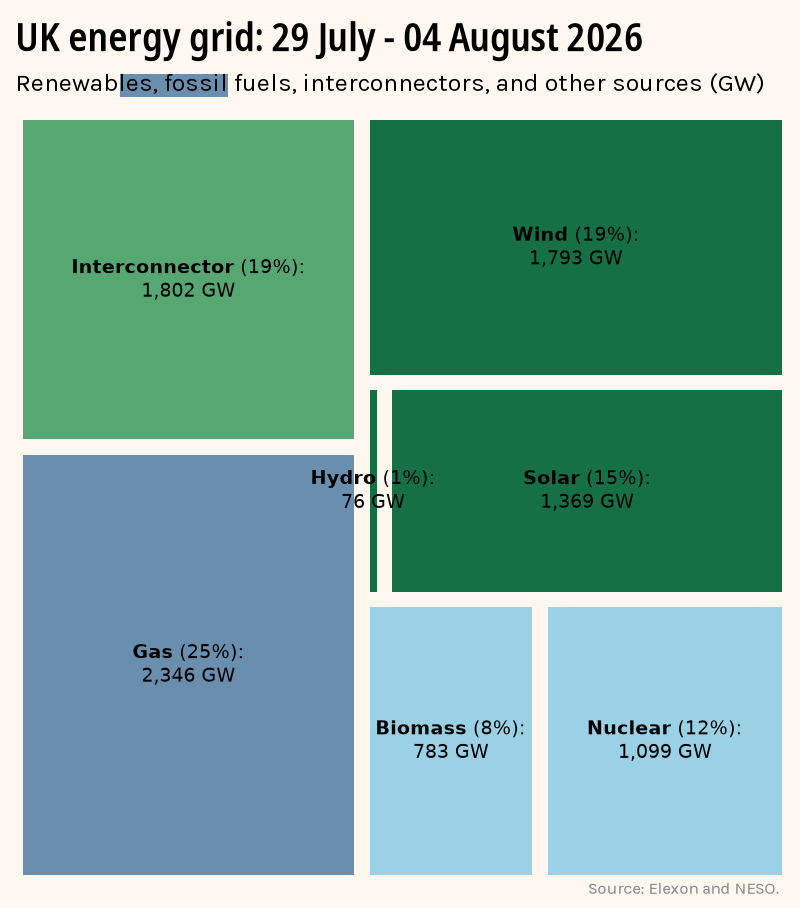

In [ ]:
# treemap data preparation
heatmap_data_test = grid_long.groupby(['category', 'source'], as_index=False)['mw'].sum()
heatmap_data_test = heatmap_data_test[heatmap_data_test['mw'] > 0].dropna(subset='mw')

interconnectors = ['INTELEC', 'INTFR', 'INTIFA2', 'INTNED', 'INTIRL', 'INTEW', 'INTGRNL', 'INTNEM', 'INTNSL', 'INTVKL']

heatmap_data_test = heatmap_data_test.assign(type = np.where(
    heatmap_data_test['source'].isin(interconnectors),
    'interconnector',
    heatmap_data_test['source']
))

# prepare final plot DataFrame
heatmap_data_test = heatmap_data_test.groupby(['category', 'type'], as_index=False)['mw'].sum()
heatmap_data_test['proportion'] = ((heatmap_data_test['mw'] / heatmap_data_test['mw'].sum()) * 100).round().astype(int)

pd.Categorical(heatmap_data_test['type'], ['biomass', 'gas', 'hydro', 'interconnector', 'nuclear', 'solar', 'wind'])

# heatmap_data_test = heatmap_data_test.sort_values(by='mw', ascending=True)


labels = [
    f"$\\bf{{{type.title()}}}$ ({proportion}%):\n{(mw / 1000):,.0f} GW"
    for type, mw, proportion in zip(heatmap_data_test['type'], heatmap_data_test['mw'], heatmap_data_test['proportion'])
]

colour_map = {
    'Fossil' : '#6A8EAE', 
    'Interconnector': '#57A773', 
    'Other': '#9BD1E5', 
    'Renewable': '#157145'
}

colors = heatmap_data_test['category'].map(colour_map)

subtitle_colours = colors.unique().tolist()

title_font = {'fontname':'Noto Sans Condensed SemiBold', 'fontsize': 28}
date_font = {'fontname':'Noto Sans Condensed SemiBold', 'fontsize': 26}
subtitle_font = {'fontname':'Karla', 'fontsize': 18}
source_font = {'fontname':'Karla', 'fontsize': 12, 'c': '#818589'}

fig, ax = plt.subplots(figsize=(10,10), facecolor="#FFF8F0")
ax.set_axis_off()

# Define text strings
main_text = f"UK energy grid: {dt.strptime(start_date, '%Y-%m-%d %H:%M:%S').strftime('%d %B')} - {(dt.strptime(start_date, '%Y-%m-%d %H:%M:%S') + timedelta(days=6)).strftime('%d %B %Y')}"
sub_text = "<Renewables>, <fossil fuels>, <interconnectors>, and <other> sources (GW)"
source_text = "Source: Elexon and NESO."

ax.text(0.0, 1.065, main_text, transform=ax.transAxes, ha='left', va='bottom', **title_font)
ax_text(0.0, 102, sub_text, transform=ax.transAxes, ha='left', va='bottom',  **subtitle_font)

ax.text(0.74, -0.02, source_text, transform=ax.transAxes, ha='left', va='bottom', **source_font)


squarify.plot(sizes=heatmap_data_test['mw'], 
              label=labels, 
              color = colors, 
              pad=True,
              text_kwargs={
        "fontsize": 14,
        "color": "black",
        "horizontalalignment": "center", 
        "verticalalignment": "center",
    })

# subtitle rectangles
rect = patches.Rectangle((13.5, 102), 14, 3, linewidth=1, facecolor=subtitle_colours[0], zorder=1, clip_on=False)

# Add the patch to the Axes
ax.add_patch(rect)

# image_output_dir = script_dir / "images"

# image_output_dir.mkdir(parents=True, exist_ok=True)

# plt.savefig(image_output_dir / "test_plot1.png", dpi=300, bbox_inches="tight")

plt.show()



In [111]:
print(f"{dt.strptime(start_date, '%Y-%m-%d %H:%M:%S').strftime('%d %B %Y')} - {(dt.strptime(start_date, '%Y-%m-%d %H:%M:%S') + timedelta(days=6)).strftime('%d %B %Y')}")

29 July 2026 - 04 August 2026


In [104]:
load_dotenv()

user = os.getenv("INSTA_USERNAME") 
password = os.getenv("PASSWORD")


In [105]:
# try:
#     cl = Client()
#     cl.login(username=user, password=password)

#     image_folder = image_output_dir
#     images = os.listdir(image_folder)

#     def post_image(image_path, caption):
#         try:
#             cl.photo_upload(path=image_path, caption=caption)
#         except Exception as e:
#             print(f"Error uploading Instagram post: {e}")
#             traceback.print_exc()

#     if images:
#         final_image = images[0]
#         caption = "A test caption for the post"
#         post_image(os.path.join(image_folder, final_image), caption)

# except Exception as e:
#     print(f"An error occurred: {e}")
#     traceback.print_exc()
# finally:
#     cl.logout()

In [106]:
# import matplotlib.font_manager
# from IPython.core.display import HTML

# def make_html(fontname):
#     return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

# code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

# HTML("<div style='column-count: 2;'>{}</div>".format(code))

In [107]:
# # plot 1 - stacked area 30 min generation
cat_data = grid_long.groupby(['timestamp', 'category'])['mw'].sum().reset_index()
cat_wide = cat_data.pivot(index='timestamp', columns='category', values='mw').fillna(0)


stackedbar = heatmap_data_test.groupby('category')['mw'].sum().reset_index()



stackedbar['x'] = "x"


print(stackedbar)

# cat_perc = cat_wide.div(cat_wide.sum(axis=1), axis=0)



# plot 2 - stacked bar weekly summary




# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,6), gridspec_kw={'width_ratios': [5, 1]},
#                                layout='constrained')

# plt.rcParams.update({'font.size': 9})
# title_font = {'fontname':'Karla',
#               'fontsize': 20}

# # colour = ['#e76f51', '#f4a261', '#2a9d8f', '#264653']
# colour = ['#6A8EAE', '#57A773', '#9BD1E5', '#157145']



# ax1.stackplot(cat_perc.index,
#               cat_perc.T,
#               labels=cat_perc.columns,
#               colors=colour)

# ax1.legend(loc="upper left")


# ax2.plot(cat_perc.index, cat_perc.iloc[:, 0], color=colour[0], marker='o')


# plt.show()


         category         mw  x
0          Fossil  2345661.0  x
1  Interconnector  1801840.0  x
2           Other  1881866.0  x
3       Renewable  3237276.0  x


In [108]:
# print(cat_data.head(10))